# Kommentarer på vad vi ska göra

* Vi kan ha en champion för varje och säga att vi hitta genom att göra CV samt med grid search, man kan nämnn generellt vad man testat

* Komma på vilken metric är vettig att dra resultat av och ge till user

* Ha några plots, som train/val loss, confusion matrix och vad mer vi tycker är intressant

* Ha animering på video på cut video?? 

* Om tid finns kanske lägga till conv NN

* Göra allt för Kinect och media pipe data, ha olika champions då borde vara bäst?? Jämföra med varandra


# Sebastians generella instruktioner från moodle 

* Submit a single, self-contained, and fully runnable notebook - I do run and debug all of your notebooks. While I do inspect your repositories, you must not rely on me trying to find where the training code is, it needs to be in the notebook.

* Do not include the datasets or pre-rendered plots. Do not put Python in formatted markdown cells. Once I run the notebook, it computes all results. If your notebook relies on earlier results or produced data, you should include it though.

* Of course you can keep the reporting for all trained variants and champion models, etc. But the notebook needs to contain one runnable version of each variant so to speak.

* Submit just the notebook, not a Zip. Only a Zip if your notebook requires auxiliary files to run.

## Handle all inputs

In [175]:
import torch.nn as nn
import torch
import mlflow
import random
import os
import glob
import copy
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)
from datetime import datetime
from sklearn.model_selection import KFold, train_test_split
import torch.optim as optim
import json
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd
from animation_tools import *
from IPython.display import Image


## Setup

In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")      # Mac GPU (Apple Silicon)
elif torch.cuda.is_available():
    device = torch.device("cuda")     # Nvidia GPU
else:
    device = torch.device("cpu")

# make sure everything has same seeds
random_seed = 42
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Squat_or_not")
mlflow.enable_system_metrics_logging()

## Create the new Y value using the kinetic cut as reference


In [155]:
def add_frame_overlap_column(full_csv_path, trimmed_csv_path, column_name="running_video"):
    df_full = pd.read_csv(full_csv_path)
    df_trimmed = pd.read_csv(trimmed_csv_path)

    trimmed_frames = set(df_trimmed["FrameNo"].values)

    values = []

    for frame in df_full["FrameNo"]:
        if frame in trimmed_frames:
            values.append(1)
        else:
            values.append(0)

    df_full[column_name] = values


    return df_full

In [152]:
trimmed_dir = "../data/kinect_good_preprocessed"

full_dir = "data/kinect_good_preprocessed_not_cut"
output_dir = "data/kinect_good_preprocessed_not_cut_start_stop"

# Paths for mediapipe
#full_dir = "../Assignment10/data/csv_of_all_videos"
#output_dir = "data/mediapipe_not_cut_start_stop"

for file_name in os.listdir(full_dir):
    if file_name.endswith(".csv"):

        full_path = os.path.join(full_dir, file_name)
        trimmed_path = os.path.join(trimmed_dir, file_name)

        if not os.path.exists(trimmed_path):
            print(f"Skipping (no match): {file_name}")
            continue

        df = add_frame_overlap_column(full_path, trimmed_path)

        output_path = os.path.join(output_dir, file_name)
        df.to_csv(output_path, index=False)

        print(f"Saved: {file_name}")

Saved: A100_kinect.csv
Saved: A11_kinect.csv
Saved: A26_kinect.csv
Saved: A137_kinect.csv
Saved: A73_kinect.csv
Saved: B9_kinect.csv
Saved: A155_kinect.csv
Saved: A44_kinect.csv
Saved: A90_kinect.csv
Saved: A149_kinect.csv
Saved: A58_kinect.csv
Saved: B4_kinect.csv
Saved: A158_kinect.csv
Saved: A3_kinect.csv
Saved: A49_kinect.csv
Saved: B17_kinect.csv
Saved: B20_kinect.csv
Saved: A81_kinect.csv
Saved: A144_kinect.csv
Saved: A55_kinect.csv
Saved: A62_kinect.csv
Saved: A37_kinect.csv
Saved: A126_kinect.csv
Saved: A111_kinect.csv
Saved: A84_kinect.csv
Saved: B12_kinect.csv
Saved: A6_kinect.csv
Saved: B1_kinect.csv
Saved: A108_kinect.csv
Saved: A19_kinect.csv
Saved: A98_kinect.csv
Saved: A67_kinect.csv
Saved: A141_kinect.csv
Saved: A50_kinect.csv
Saved: A114_kinect.csv
Saved: A32_kinect.csv
Saved: A123_kinect.csv
Saved: A23_kinect.csv
Saved: A132_kinect.csv
Saved: A105_kinect.csv
Saved: A14_kinect.csv
Saved: A150_kinect.csv
Saved: A41_kinect.csv
Saved: A76_kinect.csv
Saved: A89_kinect.csv


## **Load data** 

* First load from chosen folder 
* Split into X and Y ignore frame NO feature
* Do normalisation with base in train data on all partitions




## Functions needed

In [156]:
def split_csvfiles(datafolder, random_seed, training_prop, validation_prop):
    csv_files = []
    for f in os.listdir(datafolder):
        if f.endswith(".csv"):
            csv_files.append(f)

    random.seed(random_seed)
    random.shuffle(csv_files)

    train_n = int(len(csv_files) * training_prop)
    val_n = int(len(csv_files) * validation_prop)

    # Split
    if validation_prop == 0:
        train_files = csv_files[:train_n]
        test_files = csv_files[train_n:]

        return train_files, test_files

    else:
        train_files = csv_files[:train_n]
        val_files = csv_files[train_n: train_n + val_n]
        test_files = csv_files[train_n + val_n:]

        return train_files, val_files, test_files


def input_target_split_start_stop(dataframe):

    joints = [
        "head", "left_shoulder", "left_elbow",
        "right_shoulder", "right_elbow",
        "left_hand", "right_hand",
        "left_hip", "right_hip",
        "left_knee", "right_knee",
        "left_foot", "right_foot" ]

    input_col_names = []

    for joint in joints:
        input_col_names += [f"{joint}_x", f"{joint}_y", f"{joint}_z"]

    X = dataframe[input_col_names].copy()
    y = dataframe[["running_video"]].copy()

    return X, y


def load(files, data_dir):
    dataframes = []

    for f in files:
        path = os.path.join(data_dir, f)   
        df = pd.read_csv(path)

        # Get rid of trailing whitespace
        df.columns = df.columns.str.strip()           
        dataframes.append(df)             

    combined = pd.concat(dataframes, ignore_index=True)  # combine all

    return combined



def input_target_split(dataframe):
    input_cols = []
    for c in dataframe.columns:
        if c.endswith("_x") or c.endswith("_y") or c.endswith("_z"):
            input_cols.append(c)

    input_data = dataframe[input_cols]
    target_data = dataframe[["running_video"]]  # Binary label: 1 frame per timestep
    return input_data, target_data



def split_data_by_video(datafolder, seq_length=30, stride=30,
                        train_ratio=0.7, val_ratio=0.15, random_seed=42):
    """
    Split by VIDEO FILE to prevent ANY data leakage between train/val/test.

    Returns:
        train_x, train_y, val_x, val_y, test_x, test_y
        X shape: (n_sequences, seq_length, 39)   -- all x/y/z coords
        y shape: (n_sequences, seq_length, 1)    -- binary running_video label
    """


    csv_files = glob.glob(os.path.join(datafolder, "*.csv"))
    print(f"Found {len(csv_files)} video files")

    random.seed(random_seed)
    random.shuffle(csv_files)

    n_files = len(csv_files)
    n_train = int(n_files * train_ratio)
    n_val = int(n_files * val_ratio)

    train_files = csv_files[:n_train]
    val_files   = csv_files[n_train:n_train + n_val]
    test_files  = csv_files[n_train + n_val:]

    print(f"Train videos: {len(train_files)}, Val videos: {len(val_files)}, Test videos: {len(test_files)}")

    def extract_sequences(file_list):
        all_X, all_y = [], []
        for file_path in file_list:
            df = pd.read_csv(file_path)
            X_df, y_df = input_target_split(df)
            X_np = X_df.values.astype(np.float32)
            y_np = y_df.values.astype(np.float32)  # shape: (n_frames, 1)
            n_frames = len(df)
            for i in range(0, n_frames - seq_length + 1, stride):
                all_X.append(torch.tensor(X_np[i:i + seq_length]))
                all_y.append(torch.tensor(y_np[i:i + seq_length]))
        if not all_X:
            n_features = 39  # 13 joints x 3 coords
            return torch.empty(0, seq_length, n_features), torch.empty(0, seq_length, 1)
        return torch.stack(all_X), torch.stack(all_y)

    train_x, train_y = extract_sequences(train_files)
    val_x,   val_y   = extract_sequences(val_files)
    test_x,  test_y  = extract_sequences(test_files)

    print(f"\nTrain sequences: {len(train_x)}, Val: {len(val_x)}, Test: {len(test_x)}")
    print(f"X shape: {train_x.shape}, y shape: {train_y.shape}")

    return train_x, train_y, val_x, val_y, test_x, test_y

## Implementation

In [157]:
# A. Kinect data
data_folder = "data/kinect_good_preprocessed_not_cut_start_stop"

training_prop = 0.9
validation_prop = 0
train_files, test_files = split_csvfiles(data_folder, random_seed, training_prop, validation_prop)

# Load in combined dataframe of all the files kept in the specific split
train_data = load(train_files, data_folder)
test_data = load(test_files, data_folder)

# Split input (x, y, z) and target (running_video)
x_train, y_train = input_target_split_start_stop(train_data)
x_test, y_test = input_target_split_start_stop(test_data)

# Normalize data with the training scale
scaler = StandardScaler()
x_train_np = x_train.values
x_test_np = x_test.values

x_train_scaled = scaler.fit_transform(x_train_np)
x_test_scaled = scaler.transform(x_test_np)  # use same scaler

# Convert to tensors for the 
x_train = torch.tensor(x_train_scaled, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values, dtype=torch.float32).to(device)
x_test = torch.tensor(x_test_scaled, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values, dtype=torch.float32).to(device)


# B. Mediapipe data
data_folder_mp = "data/mediapipe_not_cut_start_stop"

training_prop = 0.9
validation_prop = 0
train_files_mp, test_files_mp = split_csvfiles(data_folder_mp, random_seed, training_prop, validation_prop)

# Load in combined dataframe of all the files kept in the specific split
train_data_mp = load(train_files_mp, data_folder_mp)
test_data_mp = load(test_files_mp, data_folder_mp)

# Split input (x, y, z) and target (running_video)
x_train_mp, y_train_mp = input_target_split_start_stop(train_data_mp)
x_test_mp, y_test_mp = input_target_split_start_stop(test_data_mp)

# Normalize data with the training scale
scaler_mp = StandardScaler()
x_train_np_mp = x_train_mp.values
x_test_np_mp = x_test_mp.values

x_train_scaled_mp = scaler_mp.fit_transform(x_train_np_mp)
x_test_scaled_mp = scaler_mp.transform(x_test_np_mp)  # use same scaler

# Convert to tensors for the 
x_train_mp = torch.tensor(x_train_scaled_mp, dtype=torch.float32).to(device)
y_train_mp = torch.tensor(y_train_mp.values, dtype=torch.float32).to(device)
x_test_mp = torch.tensor(x_test_scaled_mp, dtype=torch.float32).to(device)
y_test_mp = torch.tensor(y_test_mp.values, dtype=torch.float32).to(device)

# **Feed forward network**


## Functions for the implementation

In [158]:
# Function to load champion model/ best performing model
def load_champion_info(metadata_dir):
    path = os.path.join(metadata_dir, "champion_info.json")

    if not os.path.exists(path):
        return None

    try:
        with open(path, "r") as f:
            return json.load(f)
    except:
        return None

# Define initial weights and biases
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight) # good for ReLU
        nn.init.zeros_(m.bias)


# Define Feedforward squat classifier class
class Squatclassifier(nn.Module):
    def __init__(self, input_size, hidden_layers: list, activation="relu", dropout=0.0):
        super().__init__()

        layers = []

        activations = {"relu": nn.ReLU(),
                       "tanh": nn.Tanh(),
                       "gelu": nn.GELU(),
                       "leaky_relu": nn.LeakyReLU()
                       }
        
        act = activations[activation]
        prev_size = input_size

        # Hidden layers
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(act)

            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size

        # Output layer- 1 neuron
        layers.append(nn.Linear(prev_size, 1))

        self.network = nn.Sequential(*layers)
        self.network.apply(init_weights)
    
    def forward(self, X):
        return self.network(X)
        


# Initializes a squatclassifier model based on a configuration
def build_model(config):
    return Squatclassifier(
        input_size=config["input_size"],
        hidden_layers=config["layers"],
        activation=config["activation"],
        dropout=config["dropout"]
    ).to(device)


# Train the model
def train_one_model(model, config, x_train, y_train, x_val, y_val, loss_fn):
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    epochs = config["epochs"]

    best_val_f1 = 0
    best_state = None
    patience = 10
    epochs_no_improve = 0

    # reshape targets
    y_train = y_train.view(-1, 1)
    y_val = y_val.view(-1, 1)

    # Training loop (full-batch)
    for epoch in range(epochs):

        model.train()
        optimizer.zero_grad()

        logits = model(x_train)
        loss = loss_fn(logits, y_train)

        loss.backward()
        optimizer.step()

        # Validation
        model.eval()

        with torch.no_grad():
            val_logits = model(x_val)
            probs = torch.sigmoid(val_logits)
            preds = (probs > 0.5).float()

            val_f1 = f1_score(
                y_val.cpu().numpy(),
                preds.cpu().numpy()
            )

        # Early stopping on f1-score
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    return best_val_f1, best_state


# Cross validation function
def cross_validation(config, X, Y, k):

    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    fold_scores = []
    fold_models = []

    # Train and evaluate on each fold
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        x_train = X[train_idx].to(device)
        y_train = Y[train_idx].to(device)

        x_val = X[val_idx].to(device)
        y_val = Y[val_idx].to(device)

        # Build model
        model = build_model(config)


        val_f1, best_state = train_one_model(
            model,
            config,
            x_train,
            y_train,
            x_val,
            y_val,
            # Binary Cross Entropy/Log Loss
            loss_fn=nn.BCEWithLogitsLoss()
        )

        fold_scores.append(val_f1)
        fold_models.append(best_state)


    avg_f1 = sum(fold_scores) / len(fold_scores)


    return {
        "cv_mean_f1": avg_f1,
        "fold_scores": fold_scores,
        "fold_models": fold_models
    }

## Setup - models were found using 10-fold cv and gridsearch 
(see HugoProject/notebooks/assignment11_hugo.ipynb)

In [ ]:
# A. Kinect data model
model_root = "binary_classificator_models/fnn_classificator/on_kinect"
metadata_path = os.path.join(model_root, "metadata", "champion_info.json")
champion_info = load_champion_info(metadata_path)

# Alternatively here is the champion_info stored in local variable
# champion_info = {"model_name": "final_model",
#                "saved_at": "2026-04-28 20:11:13",
#                "f1": 0.9239302694136292,
#                "recall": 0.938430583501006,
#                "precision": 0.9098712446351931,
#                "hyperparameters": {
#                 "layers": [
#                   256,
#                   128,
#                   32
#                 ],
#                 "lr": 0.005,
#                 "dropout": 0.1,
#                 "activation": "relu",
#                 "epochs": 200,
#                 "input_size": 39
#                 }
# }

best_config = champion_info["hyperparameters"]
print("Champion config loaded for kinect data")
print(best_config)



# B. Model on Mediapipe data (gridsearch gave the same configuration as for kinect data)
model_root_mp = "binary_classificator_models/fnn_classificator/on_mediapipe"
metadata_path_mp = os.path.join(model_root_mp, "metadata", "champion_info.json")

champion_info_mp = load_champion_info(metadata_path_mp)

# Alternatively here is the champion_info_mp stored in local variable
# champion_info_mp = {"model_name": "final_model",
#                "saved_at": "2026-04-29 00:43:57",
#                "f1": 0.9195448193252146,
#                "recall": 0.9267605633802817,
#                "precision": 0.9124405705229794,
#                "hyperparameters": {
#                 "layers": [
#                   256,
#                   128,
#                   32
#                 ],
#                 "lr": 0.005,
#                 "dropout": 0.1,
#                 "activation": "relu",
#                 "epochs": 200,
#                 "input_size": 39
#                 }
# }

best_config_mp = champion_info_mp["hyperparameters"]
print("\nChampion config loaded for Mediapipe data")
print(best_config_mp)

Champion config loaded for kinect data
{'layers': [256, 128, 32], 'lr': 0.005, 'dropout': 0.1, 'activation': 'relu', 'epochs': 200, 'input_size': 39}

Champion config loaded for Mediapipe data
{'layers': [256, 128, 32], 'lr': 0.005, 'dropout': 0.1, 'activation': 'relu', 'epochs': 200, 'input_size': 39}


## Re-train

In [165]:
# A.
final_model = build_model(best_config)

# Make split for the retraining s.t model isn't overfitted to the training data
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42)

# Retrain best config from the cross validation gridsearch
_, best_state = train_one_model(final_model, best_config, x_tr, y_tr, x_val, y_val, loss_fn = nn.BCEWithLogitsLoss())


# B.
final_model_mp = build_model(best_config_mp)

# Make split for the retraining s.t model isn't overfitted to the training data
x_tr_mp, x_val_mp, y_tr_mp, y_val_mp = train_test_split(x_train_mp, y_train_mp, test_size=0.1, random_state=42)

# Retrain best config from the cross validation gridsearch
_, best_state_mp = train_one_model(final_model_mp, best_config_mp, x_tr_mp, y_tr_mp, x_val_mp, y_val_mp, loss_fn = nn.BCEWithLogitsLoss())



## Evaluate and results



In [ ]:
# A.
# Load weights from re-training
final_model.load_state_dict(best_state)

# Evaluate against test set
final_model.eval()
with torch.no_grad():
    logits = final_model(x_test.to(device))
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    f1 = f1_score(y_test.cpu(), preds.cpu())
    precision = precision_score(y_test.cpu(), preds.cpu())
    recall = recall_score(y_test.cpu(), preds.cpu())
    accuracy = accuracy_score(y_test.cpu(), preds.cpu())

    cm = confusion_matrix(y_test.cpu(), preds.cpu())

print("TEST RESULTS for FNN model on kinect data")
print(f"F1: {f1}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Accuracy: {round(accuracy * 100, 4)}%")
print("\nConfusion Matrix for best performing FNN on kinect data:")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Squat", "Squat"],
            yticklabels=["Not Squat", "Squat"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for best performing FNN on kinect data")
plt.show()


# B.
# Load weights from re-training
final_model_mp.load_state_dict(best_state_mp)

# Evaluate against test set
final_model_mp.eval()
with torch.no_grad():
    logits_mp = final_model_mp(x_test_mp.to(device))
    probs_mp = torch.sigmoid(logits_mp)
    preds_mp = (probs_mp > 0.5).float()

    f1_mp = f1_score(y_test_mp.cpu(), preds_mp.cpu())
    precision_mp = precision_score(y_test_mp.cpu(), preds_mp.cpu())
    recall_mp = recall_score(y_test_mp.cpu(), preds_mp.cpu())
    accuracy_mp = accuracy_score(y_test_mp.cpu(), preds_mp.cpu())

    cm_mp = confusion_matrix(y_test_mp.cpu(), preds_mp.cpu())

print("TEST RESULTS for FNN model on mediapipe data")
print(f"F1: {f1_mp}")
print(f"Precision: {precision_mp}")
print(f"Recall: {recall_mp}")
print(f"Accuracy: {round(accuracy_mp * 100, 4)}%")
print("\nConfusion Matrix for best performing FNN on mediapipe data:")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Squat", "Squat"],
            yticklabels=["Not Squat", "Squat"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for best performing FNN on mediapipe data")
plt.show()

# Reccurant NN

In [11]:
class MovementClassifier(nn.Module):
    """
    Sequence-to-sequence binary classifier.
    Input:  (batch, seq_len, 39)  -- 13 joints x 3 coords
    Output: (batch, seq_len, 1)   -- logit per frame (use BCEWithLogitsLoss)
    """
    def __init__(self, hidden_layers: list, layer_type="LSTM", dropout=0.0):
        super().__init__()
        self.layer_type = layer_type

        input_size = 39  # 13 joints x 3 (x, y, z)
        rnn_class = nn.LSTM if layer_type == "LSTM" else nn.GRU

        self.rnns  = nn.ModuleList()
        self.drops = nn.ModuleList()

        sizes = [input_size] + hidden_layers
        for i in range(len(hidden_layers)):
            self.rnns.append(rnn_class(sizes[i], sizes[i + 1], batch_first=True))
            self.drops.append(nn.Dropout(dropout) if dropout > 0 else nn.Identity())

        self.fc_out = nn.Linear(hidden_layers[-1], 1)  # 1 logit per frame

    def forward(self, x):
        for rnn, drop in zip(self.rnns, self.drops):
            x, _ = rnn(x)
            x = drop(x)
        return self.fc_out(x)  # (batch, seq_len, 1)


## Setup

CV mean F1: 0.9480  |  CV Std F1: 0.014749553665563356

per fold: [0.9574, 0.9629, 0.9428, 0.9282, 0.9703, 0.9432, 0.9576, 0.9521, 0.9244, 0.9415]


{
  "model_name": "lstm_cv",
  "saved_at": "2026-04-28 22:58:29",
  "f1": 0.9375,
  "recall": 0.9064612057312788,
  "precision": 0.9303551609322974,
  "hyperparameters": {
    "hidden_layers": [
      160,
      160,
      64
    ],
    "layer_type": "LSTM",
    "dropout": 0.4,
    "learning_rate": 0.0005,
    "batch_size": 32,
    "seq_length": 30,
    "stride": 30,
    "weight_decay": 1e-06
  },
  "test_results": {
    "f1": 0.895628078817734,
    "accuracy": 0.8758241758241758,
    "precision": 0.8772617611580217,
    "recall": 0.9147798742138364,
    "auc": 0.9539372310493214,
    "evaluated_at": "2026-04-28 23:01:18"
  }
}


## Load Best model

In [8]:
# Load champion model info to get best hyperparameters from previous CV
rnn_model_root  = 'binary_classificator_models/recurrant_classification'
rnn_metadata    = os.path.join(rnn_model_root, 'metadata')
rnn_champion    = os.path.join(rnn_model_root, 'champion')

champion_info = load_champion_info(rnn_metadata)

if champion_info is not None:
    print('Champion config loaded:')
    print(json.dumps(champion_info, indent=2))
    params_lstm = champion_info['hyperparameters']
    params_lstm['run_name'] = 'lstm_retrain'
    params_lstm['epochs']   = 300
    params_lstm['patience'] = 20
else:
    print('No champion found — using fallback config')
    params_lstm = {
        'hidden_layers': [160, 160, 64],
        'layer_type':    'LSTM',
        'dropout':       0.4,
        'learning_rate': 0.0005,
        'batch_size':    32,
        'seq_length':    30,
        'stride':        30,
        'weight_decay':  1e-6,
        'epochs':        300,
        'patience':      20,
        'run_name':      'lstm_retrain',
    }


No champion found — using fallback config


## Train new model

In [16]:
# ── Load & split data ────────────────────────────────────────────────────────
datafolder = 'data/kinect_good_preprocessed_not_cut_start_stop'

train_x, train_y, val_x, val_y, test_x, test_y, = split_data_by_video(
    datafolder,
    seq_length=params_lstm['seq_length'],
    stride=params_lstm['stride'],
)

# ── Scaling (fit on train only) ───────────────────────────────────────────────
scaler = StandardScaler()
n_seq, seq_len, n_feat = train_x.shape

train_x_s = torch.tensor(
    scaler.fit_transform(train_x.reshape(-1, n_feat)).reshape(n_seq, seq_len, n_feat)
).float()
val_x_s = torch.tensor(
    scaler.transform(val_x.reshape(-1, n_feat)).reshape(val_x.shape)
).float()
test_x_s = torch.tensor(
    scaler.transform(test_x.reshape(-1, n_feat)).reshape(test_x.shape)
).float()

# Use scaled tensors from here on
train_x, val_x, test_x = train_x_s, val_x_s, test_x_s

# ── Build model & optimizer ───────────────────────────────────────────────────
model = MovementClassifier(
    hidden_layers=params_lstm['hidden_layers'],
    layer_type=params_lstm['layer_type'],
    dropout=params_lstm['dropout'],
).to(device)

loss_fn   = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=params_lstm['learning_rate'],
    weight_decay=params_lstm.get('weight_decay', 0)
)

print(f'Model: {params_lstm["layer_type"]}  |  '
      f'Layers: {params_lstm["hidden_layers"]}  |  '
      f'Params: {sum(p.numel() for p in model.parameters()):,}')


Found 179 video files
Train videos: 125, Val videos: 26, Test videos: 28

Train sequences: 801, Val: 185, Test: 182
X shape: torch.Size([801, 30, 39]), y shape: torch.Size([801, 30, 1])
Model: LSTM  |  Layers: [160, 160, 64]  |  Params: 392,641


2026/04/28 23:56:06 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/28 23:56:06 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


  → New best val F1: 0.9258 (epoch 1)
  → New best val F1: 0.9284 (epoch 2)
  → New best val F1: 0.9308 (epoch 7)
Epoch 10/300 | train_loss: 0.0961  train_f1: 0.9683 | val_loss: 0.3322  val_f1: 0.9193  val_acc: 0.8939
  → New best val F1: 0.9319 (epoch 11)
  → New best val F1: 0.9345 (epoch 15)
Epoch 20/300 | train_loss: 0.1064  train_f1: 0.9636 | val_loss: 0.2921  val_f1: 0.9310  val_acc: 0.9085
  → New best val F1: 0.9365 (epoch 27)
Epoch 30/300 | train_loss: 0.0857  train_f1: 0.9726 | val_loss: 0.2853  val_f1: 0.9332  val_acc: 0.9106
Epoch 40/300 | train_loss: 0.0833  train_f1: 0.9728 | val_loss: 0.3101  val_f1: 0.9250  val_acc: 0.9002


2026/04/28 23:56:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Early stopping at epoch 47 — best val F1: 0.9365
Restored best model (val F1: 0.9365)


2026/04/28 23:56:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



✅ Test Results:
              precision    recall  f1-score   support

Not movement       0.88      0.87      0.88      2280
    Movement       0.91      0.92      0.91      3180

    accuracy                           0.90      5460
   macro avg       0.89      0.89      0.89      5460
weighted avg       0.90      0.90      0.90      5460



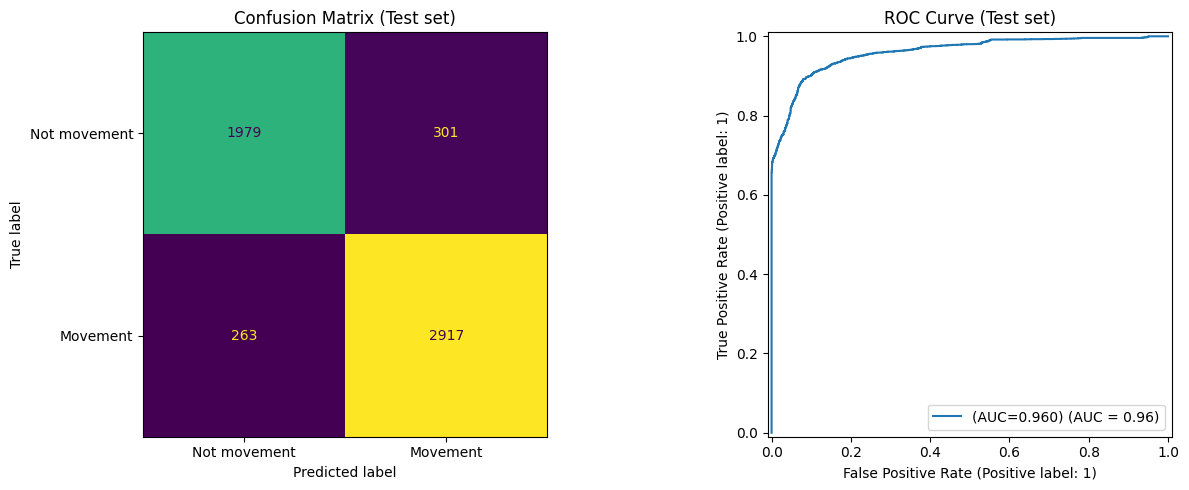

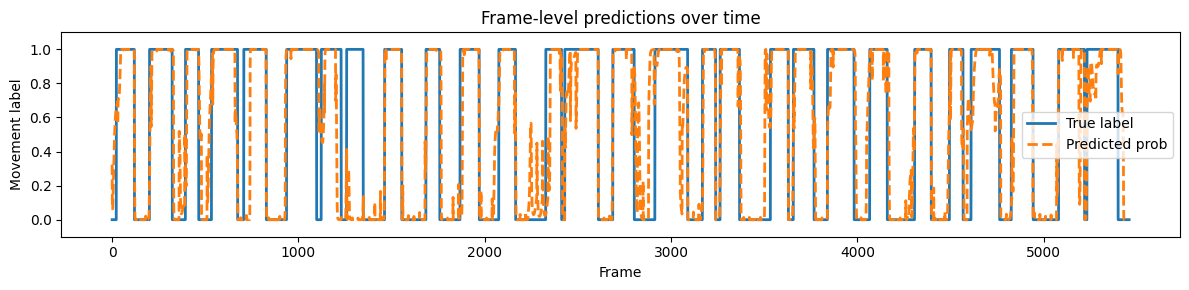

2026/04/28 23:56:17 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/28 23:56:17 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!



AUC: 0.9604  |  F1: 0.9118  |  Accuracy: 0.8967
🏃 View run lstm_retrain at: http://127.0.0.1:5000/#/experiments/5/runs/4c730986666041b7b00d0b5093c4b77c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


In [18]:
def compute_classification_metrics(logits, targets):
    """Convert logits -> binary preds and compute accuracy, F1, precision, recall."""
    probs  = torch.sigmoid(logits).cpu().numpy().flatten()
    preds  = (probs > 0.5).astype(int)
    labels = targets.cpu().numpy().flatten().astype(int)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds, zero_division=0),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "probs":     probs,
        "preds":     preds,
        "labels":    labels,
    }



with mlflow.start_run(run_name=params_lstm["run_name"]) as run:
    mlflow.log_params(params_lstm)

    train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=params_lstm["batch_size"], shuffle=True)
    val_loader   = DataLoader(TensorDataset(val_x,   val_y),   batch_size=params_lstm["batch_size"], shuffle=False)
    test_loader  = DataLoader(TensorDataset(test_x,  test_y),  batch_size=params_lstm["batch_size"], shuffle=False)

    best_val_f1       = -1.0
    best_model_state  = None
    epochs_no_improve = 0

    for epoch in range(params_lstm["epochs"]):

        # ── Training ─────────────────────────────────────────────────────────
        model.train()
        train_losses, all_train_logits, all_train_labels = [], [], []

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            optimizer.zero_grad()
            logits = model(batch_x)
            loss   = loss_fn(logits, batch_y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            all_train_logits.append(logits.detach())
            all_train_labels.append(batch_y)

        avg_train_loss   = np.mean(train_losses)
        train_m          = compute_classification_metrics(
            torch.cat(all_train_logits), torch.cat(all_train_labels)
        )

        # ── Validation ───────────────────────────────────────────────────────
        model.eval()
        val_losses, all_val_logits, all_val_labels = [], [], []

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)
                logits  = model(batch_x)
                val_losses.append(loss_fn(logits, batch_y).item())
                all_val_logits.append(logits)
                all_val_labels.append(batch_y)

        avg_val_loss = np.mean(val_losses)
        val_m        = compute_classification_metrics(
            torch.cat(all_val_logits), torch.cat(all_val_labels)
        )

        mlflow.log_metrics({
            "train_loss":      avg_train_loss,
            "train_accuracy":  train_m["accuracy"],
            "train_f1":        train_m["f1"],
            "train_precision": train_m["precision"],
            "train_recall":    train_m["recall"],
            "val_loss":        avg_val_loss,
            "val_accuracy":    val_m["accuracy"],
            "val_f1":          val_m["f1"],
            "val_precision":   val_m["precision"],
            "val_recall":      val_m["recall"],
        }, step=epoch)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{params_lstm['epochs']} "
                  f"| train_loss: {avg_train_loss:.4f}  train_f1: {train_m['f1']:.4f} "
                  f"| val_loss: {avg_val_loss:.4f}  val_f1: {val_m['f1']:.4f}  "
                  f"val_acc: {val_m['accuracy']:.4f}")

        # ── Early stopping on val F1 ──────────────────────────────────────────
        if params_lstm.get("patience"):
            if val_m["f1"] > best_val_f1:
                best_val_f1      = val_m["f1"]
                best_model_state = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
                print(f"  → New best val F1: {best_val_f1:.4f} (epoch {epoch+1})")
            else:
                epochs_no_improve += 1
            if epochs_no_improve >= params_lstm["patience"]:
                print(f"Early stopping at epoch {epoch+1} — best val F1: {best_val_f1:.4f}")
                break

    # ── Restore best model ────────────────────────────────────────────────────
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Restored best model (val F1: {best_val_f1:.4f})")

        

    # ── Test evaluation ───────────────────────────────────────────────────────
    model.eval()
    test_losses, all_test_logits, all_test_labels = [], [], []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            logits  = model(batch_x)
            test_losses.append(loss_fn(logits, batch_y).item())
            all_test_logits.append(logits)
            all_test_labels.append(batch_y)

    test_m   = compute_classification_metrics(
        torch.cat(all_test_logits), torch.cat(all_test_labels)
    )
    test_auc = roc_auc_score(test_m["labels"], test_m["probs"])

    mlflow.log_metrics({
        "test_loss":      np.mean(test_losses),
        "test_accuracy":  test_m["accuracy"],
        "test_f1":        test_m["f1"],
        "test_precision": test_m["precision"],
        "test_recall":    test_m["recall"],
        "test_auc":       test_auc,
    })
    mlflow.pytorch.log_model(model, artifact_path=f"best_model_{params_lstm['run_name']}")


    print(f"\n✅ Test Results:")
    print(classification_report(test_m["labels"], test_m["preds"],
                                target_names=["Not movement", "Movement"]))

    # ── Confusion matrix + ROC curve ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cm = confusion_matrix(test_m["labels"], test_m["preds"])
    ConfusionMatrixDisplay(cm, display_labels=["Not movement", "Movement"]).plot(
        ax=axes[0], colorbar=False
    )
    axes[0].set_title("Confusion Matrix (Test set)")
    RocCurveDisplay.from_predictions(
        test_m["labels"], test_m["probs"],
        name=f"(AUC={test_auc:.3f})", ax=axes[1]
    )
    axes[1].set_title("ROC Curve (Test set)")
    plt.tight_layout()
    plt.savefig("test_evaluation_rnn.png", dpi=150)
    mlflow.log_artifact("test_evaluation_rnn.png")
    plt.show()

    # ── Temporal prediction plot ──────────────────────────────────────────────
    n_frames_to_plot = params_lstm["seq_length"] * 200
    fig2, ax = plt.subplots(figsize=(12, 3))
    ax.plot(test_m["labels"][:n_frames_to_plot],  label="True label",     linewidth=2)
    ax.plot(test_m["probs"][:n_frames_to_plot],   label="Predicted prob", linewidth=2, linestyle="--")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Movement label")
    ax.set_title("Frame-level predictions over time")
    ax.legend()
    ax.set_ylim(-0.1, 1.1)
    plt.tight_layout()
    plt.savefig("temporal_predictions_rnn.png", dpi=150)
    mlflow.log_artifact("temporal_predictions_rnn.png")
    plt.show()

    print(f"\nAUC: {test_auc:.4f}  |  F1: {test_m['f1']:.4f}  |  Accuracy: {test_m['accuracy']:.4f}")

## Evaluate and results


# Cut video (Kinect)

In [169]:
def trim_csv_with_model_simple(model, input_csv, output_csv, threshold=0.5):
    df = pd.read_csv(input_csv)
    df.columns = df.columns.str.strip()
    
    if "FrameNo" not in df.columns:
        df["FrameNo"] = np.arange(len(df))


    feature_cols = [c for c in df.columns
        if c.endswith("_x") or c.endswith("_y") or c.endswith("_z")]


    X_np = df[feature_cols].values
    X_scaled = scaler.transform(X_np)
    X = torch.tensor(X_scaled, dtype=torch.float32).to(device)
    
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()

    preds = (probs >= threshold).astype(int)

    print("Predictions of relevant frames:")
    print(preds)
    
    df["pred_running"] = preds

    movement_frames = df[df["pred_running"] == 1]

    if len(movement_frames) == 0:
        print("No movement detected")
        return None

    start_idx = movement_frames.index.min()
    stop_idx = movement_frames.index.max()

    trimmed_df = df.loc[start_idx:stop_idx].drop(columns=["pred_running"])

    trimmed_df.to_csv(output_csv, index=False)

    print(f"Saved trimmed CSV: {output_csv}")
    print(f"Start index: {start_idx}, Stop index: {stop_idx}")

    return trimmed_df

In [185]:
# Files to test to cut
print(test_files)


['B21_kinect.csv', 'A146_kinect.csv', 'A157_kinect.csv', 'A111_kinect.csv', 'A44_kinect.csv', 'A90_kinect.csv', 'A151_kinect.csv', 'A20_kinect.csv', 'A126_kinect.csv', 'A31_kinect.csv', 'A6_kinect.csv', 'A32_kinect.csv', 'B18_kinect.csv', 'A35_kinect.csv', 'A52_kinect.csv', 'A155_kinect.csv', 'A108_kinect.csv', 'A12_kinect.csv']


In [189]:
input_path = "data/kinect_good_preprocessed_not_cut/B21_kinect.csv"
output_path = "../data/kinect_own_trimmed/B21_kinect_trimmed.csv"

trim_csv_with_model_simple(
    model=final_model,
    input_csv=input_path,
    output_csv=output_path
)

Predictions of relevant frames:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]
Saved trimmed CSV: ../data/kinect_own_trimmed/B21_kinect_trimmed.csv
Start index: 111, Stop index: 200


,FrameNo,head_x,head_y,head_z,left_shoulder_x,left_shoulder_y,left_shoulder_z,left_elbow_x,left_elbow_y,left_elbow_z,...,left_knee_z,right_knee_x,right_knee_y,right_knee_z,left_foot_x,left_foot_y,left_foot_z,right_foot_x,right_foot_y,right_foot_z
111,111,-0.009925,0.73393,0.032995,-0.15909,0.54519,-0.007979,-0.26413,0.74659,-0.089940,...,-0.051519,0.10954,-0.34084,-0.020723,-0.10152,-0.68682,0.019142,0.094830,-0.66792,0.042388
112,112,-0.009925,0.72492,0.032995,-0.15864,0.53478,-0.007149,-0.26381,0.73657,-0.090440,...,-0.055958,0.11157,-0.34452,-0.025678,-0.10155,-0.68972,0.016642,0.095111,-0.67055,0.040269
113,113,-0.009970,0.71432,0.032993,-0.15818,0.52310,-0.006174,-0.26352,0.72556,-0.090514,...,-0.060662,0.11365,-0.34847,-0.031300,-0.10163,-0.69285,0.014134,0.095554,-0.67342,0.037777
114,114,-0.010223,0.70202,0.033192,-0.15778,0.50989,-0.004985,-0.26345,0.71403,-0.090598,...,-0.066008,0.11565,-0.35268,-0.037151,-0.10159,-0.69598,0.011468,0.095977,-0.67651,0.035055
115,115,-0.010635,0.68898,0.033549,-0.15771,0.49798,-0.003977,-0.26344,0.70084,-0.090942,...,-0.071443,0.11767,-0.35766,-0.043375,-0.10150,-0.69894,0.008577,0.096474,-0.67965,0.032154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,196,-0.000990,0.71872,0.034948,-0.14619,0.51411,-0.008503,-0.25181,0.71429,-0.092726,...,-0.084491,0.12232,-0.29878,-0.069755,-0.10532,-0.66657,-0.011768,0.108800,-0.67127,-0.017156
197,197,-0.000905,0.73340,0.034841,-0.14670,0.53197,-0.009313,-0.25202,0.73073,-0.093855,...,-0.074272,0.11821,-0.29791,-0.059880,-0.10509,-0.66606,-0.007494,0.108300,-0.67097,-0.012918
198,198,-0.000800,0.74676,0.034597,-0.14710,0.54890,-0.010046,-0.25235,0.74582,-0.095135,...,-0.063720,0.11391,-0.29751,-0.049805,-0.10476,-0.66527,-0.002959,0.107680,-0.67076,-0.008559
199,199,-0.000743,0.75694,0.034413,-0.14757,0.56199,-0.010774,-0.25271,0.75965,-0.096305,...,-0.053405,0.10977,-0.29719,-0.040164,-0.10420,-0.66525,0.002454,0.106860,-0.67053,-0.003541


## Animation


Loaded 103 frames of skeleton data

Creating animation...
Animation saved as skeleton_animation.gif
Animation created successfully!


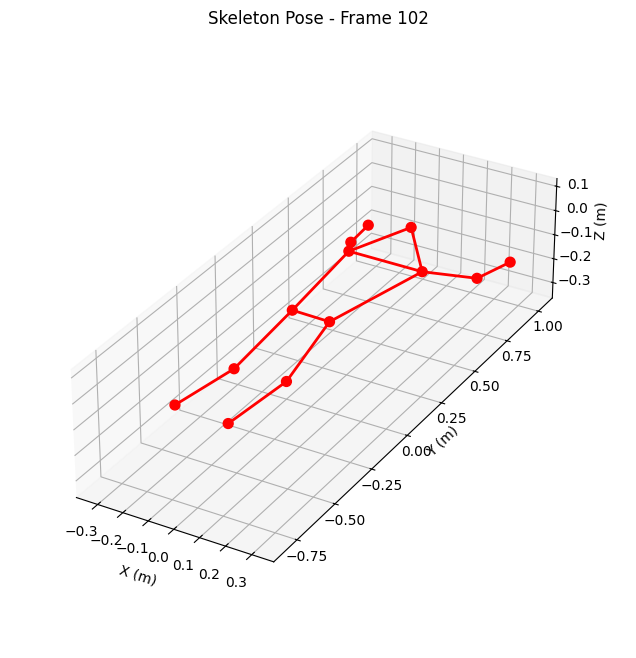

In [ ]:
#
animate(
    path="../data/kinect_good_preprocessed/B21_kinect.csv",
    save_folder_path="../plots"
)


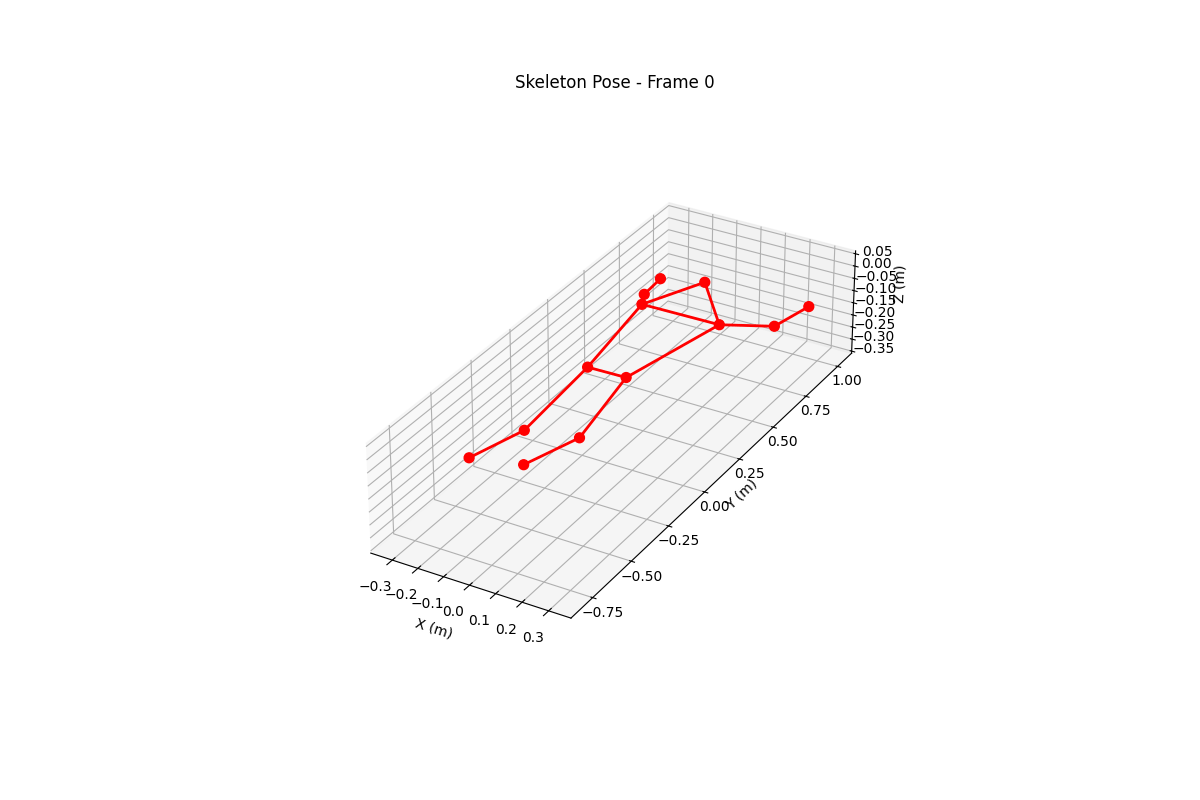

In [ ]:
# Animation for TRIMMED video using modell for kinect data
Image("../plots/B21_own_trimmed_kinect.gif")

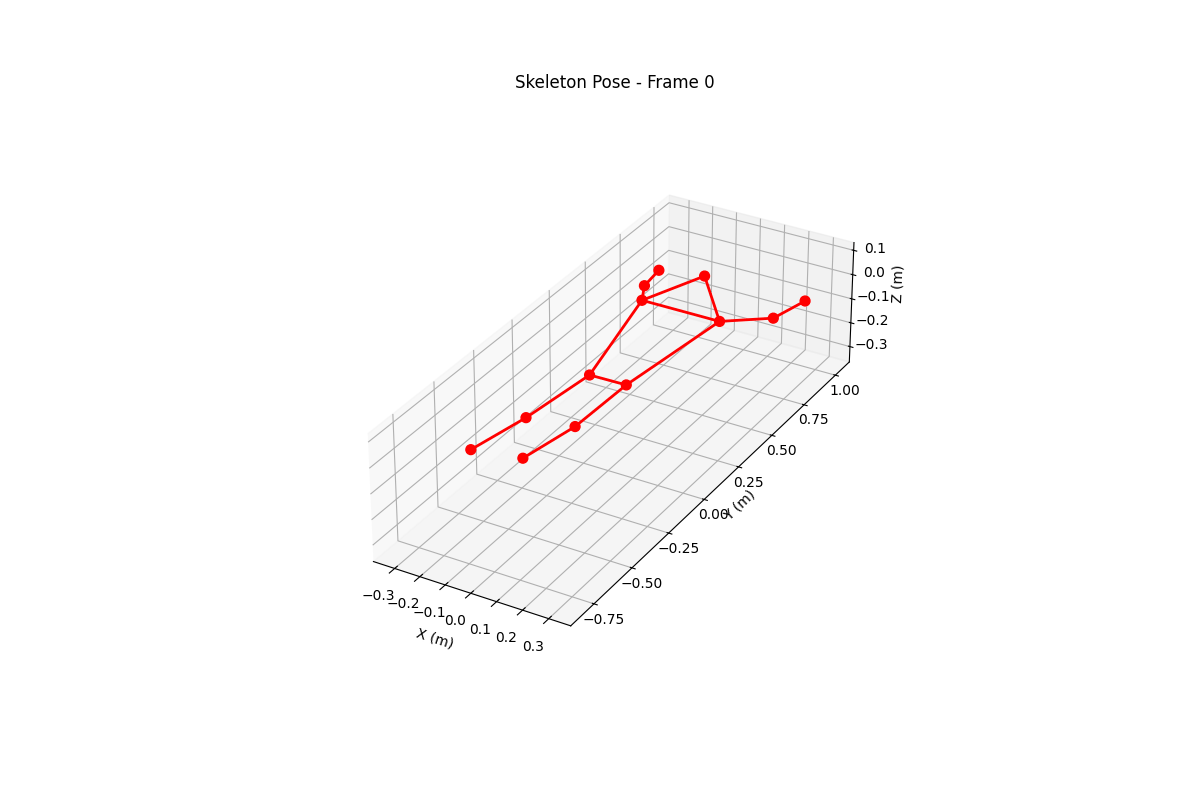

In [ ]:
# Animation for GIVEN video
Image("../plots/B21_given_trimmed_kinect.gif")

# Summary and future works